# The Anatomy of a Bubble: A GLM Analysis of Reflexivity in Gold Markets
**Author:** Yue Ju | **Course:** MATH50011 Statistical Modelling

## 1. Data Pre-Processing and Exploratory Data Analysis (EDA)
Before applying our Autoregressive Linear Models and Generalized Linear Models (GLMs), we must ensure the integrity of our dataset. 

We analyze a maximum period of 26-year synchronized window (2000–2026) for three distinct assets:
1. **Sugar:** A physical commodity bound by mean-reverting supply cycles.
2. **Bitcoin:** A purely psychological asset prone to reflexive momentum.
3. **Gold:** An asset with both physical utility and psychological safe-haven properties.

**The Inflation Adjustment:**
Comparing absolute nominal price stretches across multiple decades introduces severe macroeconomic bias. To isolate the true market microstructure—whether mean-reverting or reflexive—we deflate all historical time series to real prices using the US Consumer Price Index (CPI). 

$$\text{Real Price}_t = \text{Nominal Price}_t \times \left( \frac{\text{CPI}_{\text{today}}}{\text{CPI}_t} \right)$$

Furthermore, we aggregate the daily/monthly data into **Weekly observations** to filter out high-frequency noise while maintaining a massive asymptotic sample size ($n \approx 1000$) necessary for Maximum Likelihood Estimation.

### Visualizing the Macroeconomic Distortion with Synchronized Timeframes

Before applying our Autoregressive Linear Models and GLMs, we must address a critical data distortion: inflation. 

* **Nominal Price:** The absolute price tag recorded at that specific historical moment. 
* **Real Price:** The inflation-adjusted price, deflated using the US Consumer Price Index (CPI) to reflect true purchasing power in today's (2026) dollars.

Failing to adjust for inflation creates a mathematical illusion. It causes historical data to look artificially low and recent data to look like an unprecedented bubble, simply due to currency debasement over 26 years. By converting to Real Prices, the scale of historical speculative bubbles and physical commodity cycles becomes mathematically accurate. 

We synchronize the timeframe (2000–2026) across all assets for robust comparison, but mask the pre-2014 data for Bitcoin to accurately represent its inception date. Finally, we plot the **Real Historical Mean** (the grey dash-dot line) across all assets to visually baseline the "Pendulum" effect of mean reversion.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic styling for the plots
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

In [8]:
# 1. Load the pristine Master Dataset generated by our extractor script
# (This contains Monthly data from 1960 to 2026)
try:
    df_master = pd.read_csv('data/master_macro_dataset.csv', index_col=0, parse_dates=True)
except FileNotFoundError:
    print("❌ Error: 'master_macro_dataset.csv' not found. Please run the data_extractor.py script first!")

# 2. Define the "Modern Synchronized Era" (2010 - 2026)
start_modern = pd.to_datetime('2010-01-01')
end_modern = pd.to_datetime(datetime.today().strftime('%Y-%m-%d'))

# 3. Create a dedicated DataFrame for this modern epoch
df_modern = df_master.loc[start_modern:end_modern].copy()

print(f"✅ Master Data Loaded. Total Deep Macro Rows (1960-2026): {len(df_master)}")
print(f"✅ Modern Epoch Ready. Synchronized Rows (2010-2026): {len(df_modern)}")
df_modern.head()

✅ Master Data Loaded. Total Deep Macro Rows (1960-2026): 795
✅ Modern Epoch Ready. Synchronized Rows (2010-2026): 194


,Sugar_Nominal,Gold_Nominal,BTC_Nominal,CPI,Sugar_Real,Gold_Real,BTC_Real
2010-01-31,58.356291,1078.5,NaN,217.488,87.863934,1623.839522,NaN
2010-02-28,55.975302,1108.3,NaN,217.281,84.359297,1670.297532,NaN
2010-03-31,41.138209,1115.5,NaN,217.353,61.978063,1680.591618,NaN
2010-04-30,36.265999,1179.3,NaN,217.403,54.625116,1776.302894,NaN
2010-05-31,33.510224,1207.5,NaN,217.290,50.500520,1819.724562,NaN


✅ High-resolution epoch plot saved successfully to: ./plots/Nominal_Real_Price.png


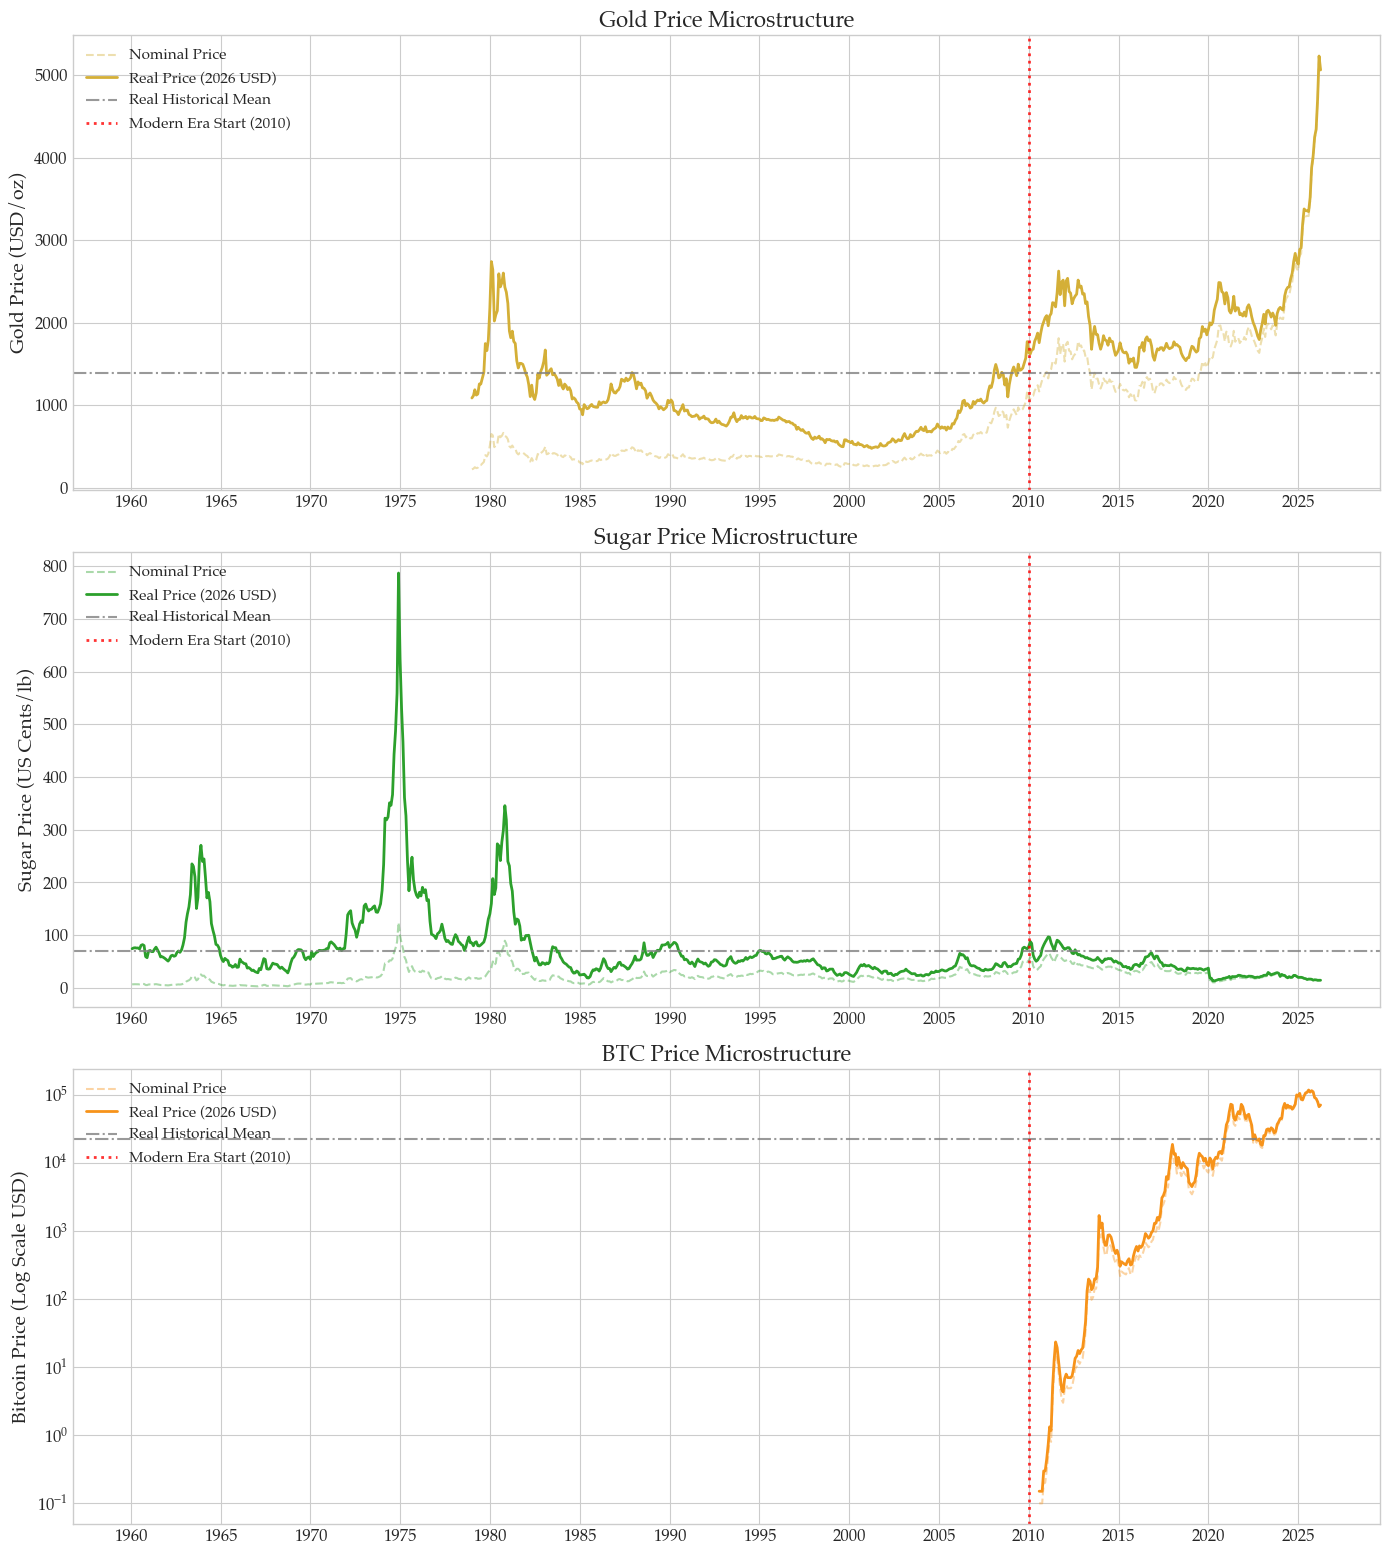

In [12]:
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
import os
import pandas as pd

# ==========================================
# FONT CONFIGURATION (Matching LaTeX mathpazo)
# ==========================================
plt.rcParams['font.family'] = 'serif'
# This tells Python to look for Palatino, and if it can't find it, use a standard Serif fallback
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'Book Antiqua', 'serif']
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 11

# 1. Ensure the plots directory exists
os.makedirs('plots', exist_ok=True)

# 2. Create figure and maintain the large height
fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

assets = ['Gold', 'Sugar', 'BTC']
colors = ['#D4AF37', '#2CA02C', '#F7931A'] # Gold, Green, Orange
y_labels = ['Gold Price (USD/oz)', 'Sugar Price (US Cents/lb)', 'Bitcoin Price (USD)']

# Define the epoch transition date (Start of the Synchronized Era)
epoch_line = pd.to_datetime('2010-01-01')

for i, asset in enumerate(assets):
    ax = axes[i]
    
    # Define columns to plot
    nominal_col = f'{asset}_Nominal'
    real_col = f'{asset}_Real'
    
    # Using df_master ensures we grab the MAXIMUM history available for each asset.
    plot_df = df_master[[nominal_col, real_col]].dropna()
    
    # Plot Nominal Price
    ax.plot(plot_df.index, plot_df[nominal_col], 
            label='Nominal Price', color=colors[i], alpha=0.4, linestyle='--', linewidth=1.5)
    
    # Plot Real Price
    ax.plot(plot_df.index, plot_df[real_col], 
            label='Real Price (2026 USD)', color=colors[i], alpha=1.0, linewidth=2.0)
    
    # EXPLICIT REAL MEAN: Calculate and plot the Real Historical Mean
    real_mean = plot_df[real_col].mean()
    ax.axhline(y=real_mean, color='grey', linestyle='-.', alpha=0.8, linewidth=1.5, 
               label=f'Real Historical Mean')
    
    # Draw the Epoch Marker (Vertical Line)
    ax.axvline(x=epoch_line, color='red', linestyle=':', linewidth=2, alpha=0.8,
               label='Modern Era Start (2010)')
        
    # General subplot formatting
    ax.set_title(f'{asset} Price Microstructure', fontweight='bold')
    ax.set_ylabel(y_labels[i])
    
    # Move legend to the upper left to stay out of the way of modern price action
    ax.legend(loc='upper left', framealpha=0.9)
    
    # Use log scale for Bitcoin due to massive exponential growth
    if asset == 'BTC':
        ax.set_yscale('log')
        ax.set_ylabel('Bitcoin Price (Log Scale USD)')

    # --- ADD X-AXIS labels (Year Stamps) to ALL subplots ---
    ax.xaxis.set_major_locator(YearLocator(5)) 
    ax.xaxis.set_major_formatter(DateFormatter('%Y'))
    ax.xaxis.set_tick_params(labelbottom=True, rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.90]) 

# 3. Save the high-resolution image
output_path = './plots/Nominal_Real_Price.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ High-resolution epoch plot saved successfully to: {output_path}")

plt.show()

## 2. Statistical Modelling and Hypothesis Testing

With the data engineered into weekly, inflation-adjusted (Real) prices, we proceed to mathematically classify the market microstructure of our three assets. 

**Part A: The Autoregressive Baseline (AR Model)**
We first run an Ordinary Least Squares (OLS) regression on the lagged weekly returns: $R_t = \beta_0 + \beta_1 R_{t-1} + \epsilon_t$. 
* We expect Sugar to yield a negative $\hat{\phi}_1$ (mean-reversion).
* We expect Bitcoin to yield a positive $\hat{\phi}_1$ (reflexive momentum).

**Part B: The "Soros Snap" Tail-Risk (GLM)**
Next, we define a catastrophic crash ($Y_t = 1$) as a weekly return falling below the asset's historical 5th percentile. We use a Generalized Linear Model (Logistic Regression) to test if the 12-month rolling cumulative return ($X_t$, the "Stretch") can predict this crash. 

To validate the model, we calculate:
1. **Likelihood Ratio Test (LRT):** Comparing our GLM against a restricted (intercept-only) null model.
2. **ROC-AUC Score:** To evaluate the out-of-sample discriminative power of the model despite the overlapping data windows.

In [18]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

results_list = []

for asset in ['Sugar', 'BTC', 'Gold']:
    # 1. Isolate Asset Data cleanly from the Modern Epoch
    # Using dropna() naturally handles Bitcoin's later start date!
    asset_df = df_modern[[f'{asset}_Real']].dropna().copy()
        
    # Calculate R_t (Monthly Real Return)
    asset_df['R_t'] = asset_df[f'{asset}_Real'].pct_change()
    
    # Calculate R_{t-1} for the AR(1) baseline model
    asset_df['R_t_minus_1'] = asset_df['R_t'].shift(1)
    
    # Calculate Stretch_X (12-Month Rolling Sum of Log Returns)
    asset_df['Log_Return'] = np.log(asset_df[f'{asset}_Real'] / asset_df[f'{asset}_Real'].shift(1))
    asset_df['Stretch_X'] = asset_df['Log_Return'].rolling(window=12).sum()
    
    # Define Crash_Y (1 if monthly return is below the 5th percentile, else 0)
    threshold = asset_df['R_t'].quantile(0.05)
    asset_df['Crash_Y'] = (asset_df['R_t'] < threshold).astype(int)
    
    # Drop rows with NaNs (caused by lagging and rolling windows)
    clean_df = asset_df.dropna()
    
    # Count total crashes
    total_crashes = int(clean_df['Crash_Y'].sum())

    # ==========================================
    # 2. The Baseline AR(1) Model (OLS)
    # ==========================================
    X_ar = sm.add_constant(clean_df['R_t_minus_1'])
    y_ar = clean_df['R_t']
    ar_model = sm.OLS(y_ar, X_ar).fit()
    beta_1_ar = ar_model.params['R_t_minus_1']
    p_val_ar = ar_model.pvalues['R_t_minus_1']

    # ==========================================
    # 3. The "Soros Snap" GLM (Logit)
    # ==========================================
    X_glm = sm.add_constant(clean_df['Stretch_X'])
    y_glm = clean_df['Crash_Y']
    
    try:
        glm_model = sm.Logit(y_glm, X_glm).fit(disp=0) 
        beta_1_glm = glm_model.params['Stretch_X']
        
        # Fit Restricted Model (Intercept Only) to get Null Log-Likelihood
        glm_restricted = sm.Logit(y_glm, np.ones(len(y_glm))).fit(disp=0)
        
        # Calculate Likelihood Ratio Test Statistic (Lambda)
        lr_stat = -2 * (glm_restricted.llf - glm_model.llf)
        lr_pval = glm_model.llr_pvalue
        
        # Calculate ROC-AUC Score
        predictions = glm_model.predict(X_glm)
        auc_score = roc_auc_score(y_glm, predictions)
        
    except Exception as e:
        print(f"Error fitting GLM for {asset}: {e}")
        beta_1_glm, lr_stat, lr_pval, auc_score = [np.nan] * 4

    # ==========================================
    # 4. Store and Format Results
    # ==========================================
    results_list.append({
        'Asset': asset,
        'N (Months)': len(clean_df),
        'Crashes (Sum Y_t)': total_crashes,
        'Beta_1 (AR)': f"{beta_1_ar:.4f}",
        'p-value (AR)': f"{p_val_ar:.4f}",
        'Beta_1 (GLM)': f"{beta_1_glm:.4f}",
        'LRT Lambda': f"{lr_stat:.4f}",
        'p-value (LRT)': "< 0.001" if lr_pval < 0.001 else f"{lr_pval:.4f}",
        'ROC-AUC': f"{auc_score:.4f}"
    })

# Convert to a DataFrame and display
results_df = pd.DataFrame(results_list)
print("\n=== Data for LaTeX Table 1 (12-Month Synchronized Era) ===")
display(results_df)


=== Data for LaTeX Table 1 (12-Month Synchronized Era) ===


,Asset,N (Months),Crashes (Sum Y_t),Beta_1 (AR),p-value (AR),Beta_1 (GLM),LRT Lambda,p-value (LRT),ROC-AUC
0,Sugar,182,8,-0.0306,0.6813,-1.1689,1.0145,0.3138,0.5596
1,BTC,176,10,0.1009,0.1794,0.5962,6.3249,0.0119,0.6645
2,Gold,182,10,-0.0090,0.9051,-3.0100,2.1450,0.1430,0.6186


In [17]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

results_list_deep = []

# We only loop through Sugar and Gold for the 60-year deep history
for asset in ['Sugar', 'Gold']:
    
    # 1. Isolate Asset Data cleanly from the FULL MASTER DATASET (1960 - 2026)
    # Using df_master instead of df_modern gives us the maximum available history!
    asset_df = df_master[[f'{asset}_Real']].dropna().copy()
        
    # Calculate R_t (Monthly Real Return)
    asset_df['R_t'] = asset_df[f'{asset}_Real'].pct_change()
    
    # Calculate R_{t-1} for the AR(1) baseline model
    asset_df['R_t_minus_1'] = asset_df['R_t'].shift(1)
    
    # Calculate Stretch_X (12-Month Rolling Sum of Log Returns)
    asset_df['Log_Return'] = np.log(asset_df[f'{asset}_Real'] / asset_df[f'{asset}_Real'].shift(1))
    asset_df['Stretch_X'] = asset_df['Log_Return'].rolling(window=12).sum()
    
    # Define Crash_Y (1 if monthly return is below the 5th percentile, else 0)
    threshold = asset_df['R_t'].quantile(0.05)
    asset_df['Crash_Y'] = (asset_df['R_t'] < threshold).astype(int)
    
    # Drop rows with NaNs (caused by lagging and rolling windows)
    clean_df = asset_df.dropna()
    
    # Count total crashes
    total_crashes = int(clean_df['Crash_Y'].sum())

    # ==========================================
    # 2. The Baseline AR(1) Model (OLS)
    # ==========================================
    X_ar = sm.add_constant(clean_df['R_t_minus_1'])
    y_ar = clean_df['R_t']
    ar_model = sm.OLS(y_ar, X_ar).fit()
    beta_1_ar = ar_model.params['R_t_minus_1']
    p_val_ar = ar_model.pvalues['R_t_minus_1']

    # ==========================================
    # 3. The "Soros Snap" GLM (Logit)
    # ==========================================
    X_glm = sm.add_constant(clean_df['Stretch_X'])
    y_glm = clean_df['Crash_Y']
    
    try:
        glm_model = sm.Logit(y_glm, X_glm).fit(disp=0) 
        beta_1_glm = glm_model.params['Stretch_X']
        
        # Fit Restricted Model (Intercept Only) to get Null Log-Likelihood
        glm_restricted = sm.Logit(y_glm, np.ones(len(y_glm))).fit(disp=0)
        
        # Calculate Likelihood Ratio Test Statistic (Lambda)
        lr_stat = -2 * (glm_restricted.llf - glm_model.llf)
        lr_pval = glm_model.llr_pvalue
        
        # Calculate ROC-AUC Score
        predictions = glm_model.predict(X_glm)
        auc_score = roc_auc_score(y_glm, predictions)
        
    except Exception as e:
        print(f"Error fitting GLM for {asset}: {e}")
        beta_1_glm, lr_stat, lr_pval, auc_score = [np.nan] * 4

    # ==========================================
    # 4. Store and Format Results
    # ==========================================
    results_list_deep.append({
        'Asset': asset,
        'N (Months)': len(clean_df),
        'Crashes (Sum Y_t)': total_crashes,
        'Beta_1 (AR)': f"{beta_1_ar:.4f}",
        'p-value (AR)': f"{p_val_ar:.4f}",
        'Beta_1 (GLM)': f"{beta_1_glm:.4f}",
        'LRT Lambda': f"{lr_stat:.4f}",
        'p-value (LRT)': "< 0.001" if lr_pval < 0.001 else f"{lr_pval:.4f}",
        'ROC-AUC': f"{auc_score:.4f}"
    })

# Convert to a DataFrame and display
results_df_deep = pd.DataFrame(results_list_deep)
print("\n=== Data for Deep Macro Baseline (1960-2026) ===")
display(results_df_deep)


=== Data for Deep Macro Baseline (1960-2026) ===


,Asset,N (Months),Crashes (Sum Y_t),Beta_1 (AR),p-value (AR),Beta_1 (GLM),LRT Lambda,p-value (LRT),ROC-AUC
0,Sugar,783,39,0.2556,0.0000,-1.3315,13.5827,< 0.001,0.6544
1,Gold,556,29,-0.0035,0.9352,-3.3443,10.2391,0.0014,0.6373


✅ High-resolution Case Study plot saved to: ./plots/Gold_Case_Study_Soros_Snap.png


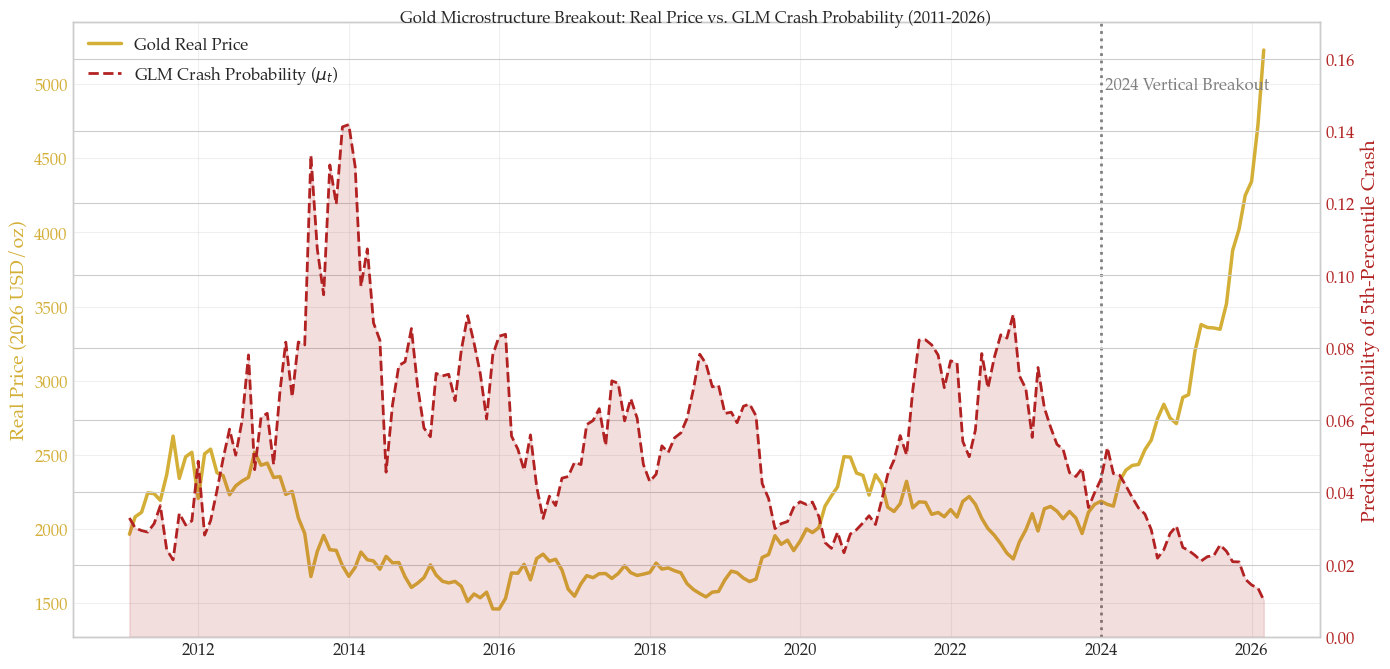

In [19]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
import os

# ==========================================
# FONT CONFIGURATION (Matching LaTeX mathpazo)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'Book Antiqua', 'serif']
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

# 1. Isolate and Prepare Gold Data for the Modern Era
gold_df = df_modern[['Gold_Real']].dropna().copy()
gold_df['R_t'] = gold_df['Gold_Real'].pct_change()
gold_df['Log_Return'] = np.log(gold_df['Gold_Real'] / gold_df['Gold_Real'].shift(1))
gold_df['Stretch_X'] = gold_df['Log_Return'].rolling(window=12).sum()

threshold = gold_df['R_t'].quantile(0.05)
gold_df['Crash_Y'] = (gold_df['R_t'] < threshold).astype(int)
clean_gold = gold_df.dropna()

# 2. Fit the GLM Model to get the Probabilities
X_glm = sm.add_constant(clean_gold['Stretch_X'])
y_glm = clean_gold['Crash_Y']
glm_model = sm.Logit(y_glm, X_glm).fit(disp=0)

# Extract Predicted Probabilities (mu_t)
clean_gold['Crash_Probability'] = glm_model.predict(X_glm)

# 3. Create the Dual-Axis Plot
fig, ax1 = plt.subplots(figsize=(14, 7))
fig.suptitle('Gold Microstructure Breakout: Real Price vs. GLM Crash Probability (2011-2026)', 
             fontweight='bold', y=0.95)

# Axis 1: Real Price (Left Y-Axis)
color1 = '#D4AF37' # Gold
ax1.plot(clean_gold.index, clean_gold['Gold_Real'], color=color1, linewidth=2.5, label='Gold Real Price')
ax1.set_ylabel('Real Price (2026 USD/oz)', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)

# Axis 2: Predicted Probability (Right Y-Axis)
ax2 = ax1.twinx()  
color2 = '#B22222' # Firebrick Red
ax2.plot(clean_gold.index, clean_gold['Crash_Probability'], color=color2, linewidth=2.0, 
         linestyle='--', label='GLM Crash Probability ($\mu_t$)')
ax2.fill_between(clean_gold.index, 0, clean_gold['Crash_Probability'], color=color2, alpha=0.15)
ax2.set_ylabel('Predicted Probability of 5th-Percentile Crash', color=color2, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, clean_gold['Crash_Probability'].max() * 1.2) # Add some breathing room at the top

# Mark the 2024 Breakout Event
breakout_date = pd.to_datetime('2024-01-01')
ax1.axvline(x=breakout_date, color='grey', linestyle=':', linewidth=2)
ax1.text(breakout_date, clean_gold['Gold_Real'].max() * 0.95, ' 2024 Vertical Breakout', 
         color='grey', fontsize=12, fontweight='bold')

# Formatting X-Axis
ax1.xaxis.set_major_locator(YearLocator(2))
ax1.xaxis.set_major_formatter(DateFormatter('%Y'))
ax1.grid(True, alpha=0.3)

# Combine Legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', framealpha=0.9)

plt.tight_layout()

# Save the plot
os.makedirs('plots', exist_ok=True)
output_path = './plots/Gold_Case_Study_Soros_Snap.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ High-resolution Case Study plot saved to: {output_path}")

plt.show()

### 3. Case Study Visualization: Modern Era Microstructure (2010–2026)

This code block generates the culminating multi-panel visualization of the study. It computes and plots the dynamic relationship between an asset's real price and its mathematically predicted probability of experiencing a tail-risk crash, allowing us to visually compare the microstructures of Bitcoin, Sugar, and Gold.

#### How the Crash Probability ($\mu_t$) is Calculated
The script iterates through each asset and dynamically calculates the crash probability using a Generalized Linear Model (GLM) with a Logistic (Logit) link function. The data pipeline follows these exact steps:

1. **Calculate the "Stretch" ($X_t$):** We compute the rolling 12-month cumulative log-return. This quantifies the magnitude of the macroeconomic price expansion (the "bubble") leading up to the current month.
2. **Define the "Crash" Threshold ($Y_t$):** We construct a binary dependent variable that equals 1 if the asset's monthly real return falls strictly below its historical 5th percentile (a severe tail-risk event), and 0 otherwise.
3. **Fit the Logistic Regression:** We regress the crash events against the 12-month stretch using the `statsmodels` Logit function:
   $$\log\left(\frac{\mu_t}{1 - \mu_t}\right) = \beta_0 + \beta_1 X_t$$
4. **Extract Predicted Probabilities:** The model outputs $\mu_t$, the continuous, dynamic probability of a crash occurring in any given month based solely on the magnitude of the trailing 12-month price stretch.

#### Visualization Architecture
To cleanly visualize this relationship, the code constructs a Dual-Axis Subplot for each asset:

* **Left Y-Axis (Solid Line):** The real, inflation-adjusted price of the asset. (Note: Bitcoin is plotted on a logarithmic scale due to its historical exponential growth profile).
* **Right Y-Axis (Dashed Red Line):** The GLM-predicted crash probability ($\mu_t$).
* **The 2024 Breakout Marker:** A red dashed vertical line is placed at January 2024 to demarcate the beginning of Gold's unprecedented structural divergence.
* **Gold Anomaly Annotation:** The final data point for Gold is explicitly annotated with a horizontal dashed grey line and the specific probability value (0.0102). This highlights the model's anomalous prediction of absolute safety despite the vertical, reflexive price stretch.

✅ Modern Era plot saved to: ./plots/case_study.png


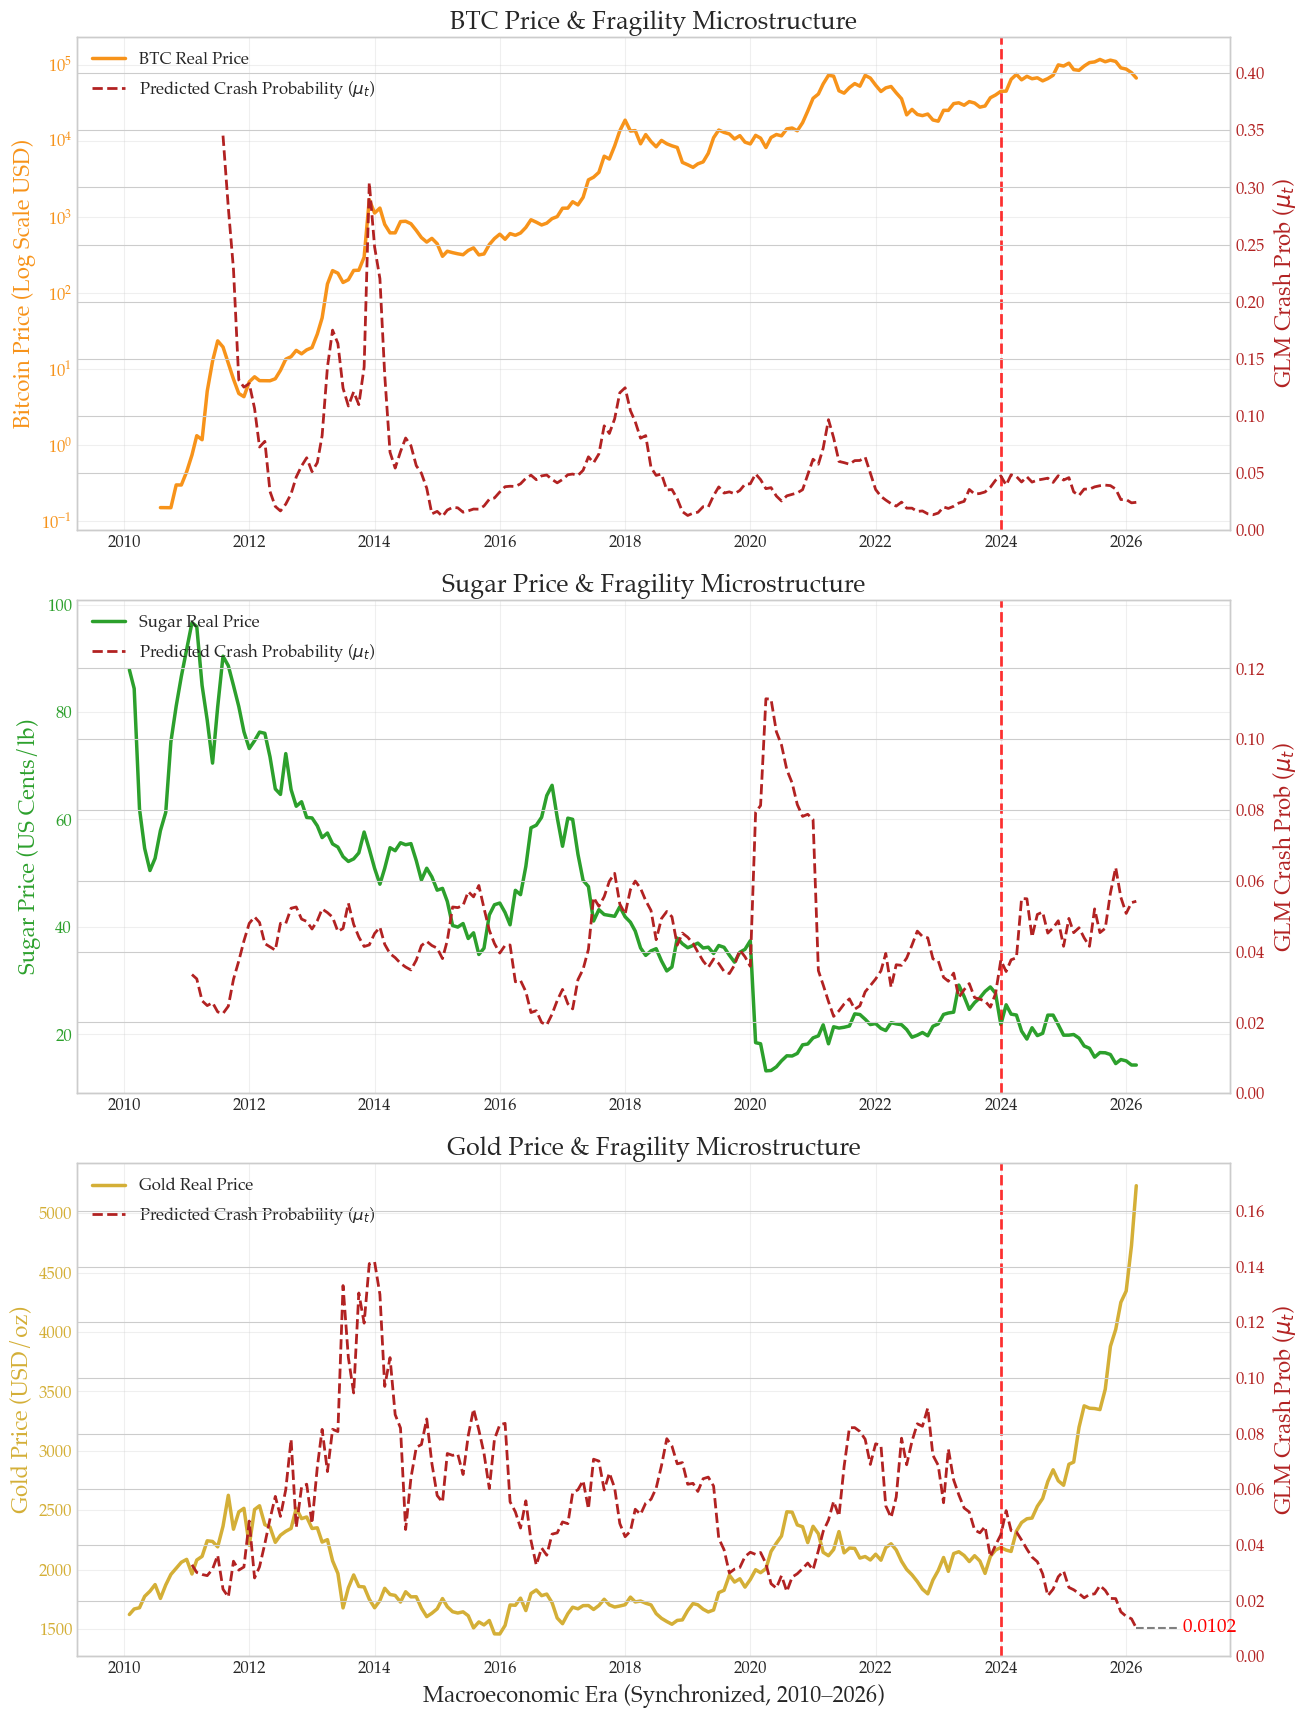

In [23]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.dates import YearLocator, DateFormatter
import os

os.makedirs('plots', exist_ok=True)

plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

assets = ['BTC', 'Sugar', 'Gold']
colors = ['#F7931A', '#2CA02C', '#D4AF37'] 
labels = ['Bitcoin Price (Log Scale USD)', 'Sugar Price (US Cents/lb)', 'Gold Price (USD/oz)']

fig, axes = plt.subplots(3, 1, figsize=(14, 20), sharex=True)

vertical_line_date = pd.to_datetime('2024-01-01')

for i, asset in enumerate(assets):
    ax1 = axes[i]
    color = colors[i]
    
    data = df_modern[[f'{asset}_Real']].dropna().copy()
    data['R_t'] = data[f'{asset}_Real'].pct_change()
    data['Log_Return'] = np.log(data[f'{asset}_Real'] / data[f'{asset}_Real'].shift(1))
    data['Stretch_X'] = data['Log_Return'].rolling(window=12).sum()
    
    threshold = data['R_t'].quantile(0.05)
    data['Crash_Y'] = (data['R_t'] < threshold).astype(int)
    
    clean_glm_data = data.dropna()
    X_glm = sm.add_constant(clean_glm_data['Stretch_X'])
    y_glm = clean_glm_data['Crash_Y']
    glm_model = sm.Logit(y_glm, X_glm).fit(disp=0) 
    clean_glm_data['Crash_Probability'] = glm_model.predict(X_glm)
    
    ln1 = ax1.plot(data.index, data[f'{asset}_Real'], color=color, linewidth=2.5, label=f'{asset} Real Price')
    ax1.set_ylabel(labels[i], color=color, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color)
    
    if asset == 'BTC':
        ax1.set_yscale('log')

    ax2 = ax1.twinx() 
    ln2 = ax2.plot(clean_glm_data.index, clean_glm_data['Crash_Probability'], color='#B22222', 
                   linewidth=2.0, linestyle='--', label='Predicted Crash Probability ($\mu_t$)')
    ax2.set_ylabel('GLM Crash Prob ($\mu_t$)', color='#B22222', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#B22222')
    ax2.set_ylim(0, clean_glm_data['Crash_Probability'].max() * 1.25) 
    
    lns = ln1 + ln2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper left')

    ax1.set_title(f'{asset} Price & Fragility Microstructure', fontsize=18, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axvline(x=vertical_line_date, color='red', linestyle='--', linewidth=2, alpha=0.8)

    # Force X-axis labels to show on ALL subplots, fixing the missing years issue
    ax1.tick_params(labelbottom=True)
    ax1.xaxis.set_major_locator(YearLocator(2))
    ax1.xaxis.set_major_formatter(DateFormatter('%Y'))

    if asset == 'Gold':
        newest_date = clean_glm_data.index[-1]
        end_date = newest_date + pd.DateOffset(months=8) 
        ax2.plot([newest_date, end_date], [0.0102, 0.0102], color='grey', linestyle='--', linewidth=1.5)
        ax2.text(end_date, 0.0102, ' 0.0102', color='red', fontsize=14, fontweight='bold', va='center')

axes[2].set_xlabel('Macroeconomic Era (Synchronized, 2010–2026)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 0.95, 0.90]) 

output_path = './plots/case_study.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✅ Modern Era plot saved to: {output_path}")
plt.show()